# Modelo Compacto: 1D-CNN sobre Curvas Térmicas (Modelo 4)

Este cuaderno implementa el entrenamiento y la evaluación de la arquitectura **1D-CNN** diseñada para estimar el tiempo transcurrido utilizando curvas numéricas de enfriamiento compactas.

### Características del enfoque:
1. **Entrada Compacta:** En lugar de leer imágenes térmicas pesadas `.npy`, el modelo se alimenta directamente de las 4 variables físicas precalculadas en `metadata_train.csv`:
   * `hot_delta_tmean_C_p95`: Temperatura media diferencial del área más caliente.
   * `hot_area_px_p95`: Área activa de la huella en píxeles.
   * `delta_tmean_C`: Cambio medio de temperatura respecto al fondo.
   * `img_tmax_C`: Temperatura máxima registrada.
2. **Ventanas Móviles 1D:** Genera ventanas deslizantes temporales de tamaño $W=5$ pasos de tiempo dentro del mismo contacto (`sequence_id`).
3. **Velocidad Extrema:** Dado que procesa únicamente vectores numéricos de baja dimensionalidad, el entrenamiento completo toma solo un par de segundos en CPU o GPU.

In [2]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.models.cnn_1d import Thermal1DCNN
from src.loaders.cnn_1d_loader import Thermal1DDataset
from src.utils import SqrtScaledMSELoss, eval_cnn_1d_metrics, build_subject_split_plan, subject_summary, sequence_ids_for_subjects, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [4]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.001,
    "weight_decay": 0.0005,
    "min_time_s": 0.0,
    "seq_len": 5,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Partición de Secuencias y Carga de Datasets (Sin Data Leakage)

Dividimos los datos por secuencias físicas. Para prevenir fugas de información, calculamos la media y desviación estándar de las variables físicas en el conjunto de **entrenamiento** y las aplicamos en la normalización de **validación**.

In [5]:
dev = CONFIG["device"]
metadata_path = "../processed_data/metadata_train.csv"
df = pd.read_csv(metadata_path)

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=5,
    seed=42,
    test_subjects=["tania"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects}, Val subjects {f.val_subjects}")

Resumen de sujetos en metadata:
        name  n_sequences  n_samples      surface  gender  is_complete
0     alonso            3        141        glass    male        False
1     angelo            6        281  glass, wood    male         True
2    eduardo            1         47         wood    male        False
3    esteban            6        276  glass, wood    male         True
4   fabricio            6        303  glass, wood    male         True
5    johamin            2         93         wood    male        False
6  juandiego            6        355  glass, wood    male         True
7     matias            6        282  glass, wood    male         True
8     renato            3        141         wood    male        False
9      tania            6        278  glass, wood  female         True

Plan de partición:
Sujetos de Test (5): ['alonso', 'eduardo', 'johamin', 'renato', 'tania'] (Muestras: 700)
Sujetos de Train/Val (5): ['angelo', 'esteban', 'fabricio', 'juandiego', 'mati

### 4. Inicialización del Modelo, Pérdida y Optimización

In [6]:
dev = CONFIG["device"]
# Imprimimos parámetros del modelo por defecto (el canal de entrada típico es 12)
model = Thermal1DCNN(in_channels=12).to(dev)
print(f"Modelo 1D-CNN cargado con {sum(p.numel() for p in model.parameters()):,} parámetros")

Modelo 1D-CNN cargado con 9,825 parámetros


--- 
## FASE A: Entrenamiento del Modelo Baseline (Sin Tunear)

Esta sección entrena el modelo 1D-CNN sobre curvas térmicas con los hiperparámetros por defecto.

In [7]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.001,
    "weight_decay": 0.0005,
}

set_seed(42)

fold_metrics_base = []
histories_base = []

print("=" * 60)
print("FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_seq_ids = sequence_ids_for_subjects(df, fold.train_subjects)
    val_seq_ids = sequence_ids_for_subjects(df, fold.val_subjects)
    
    train_ds = Thermal1DDataset(
        metadata_csv=metadata_path,
        is_train=True,
        min_time_s=CONFIG["min_time_s"],
        seq_len=CONFIG["seq_len"],
        sequence_ids=train_seq_ids
    )
    val_ds = Thermal1DDataset(
        metadata_csv=metadata_path,
        is_train=False,
        min_time_s=CONFIG["min_time_s"],
        seq_len=CONFIG["seq_len"],
        sequence_ids=val_seq_ids,
        means=train_ds.means,
        stds=train_ds.stds
    )
    
    train_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BASELINE_CONFIG["batch_size"])
    train_eval_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"])
    
    model = Thermal1DCNN(in_channels=len(train_ds.feature_cols)).to(dev)
    crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, BASELINE_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_seq, y in train_loader:
            x_seq, y = x_seq.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_seq), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_seq.size(0)
            n += x_seq.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_seq, val_y in val_loader:
                val_x_seq, val_y = val_x_seq.to(dev), val_y.to(dev)
                loss = crit(model(val_x_seq), val_y)
                val_loss += loss.item() * val_x_seq.size(0)
                val_n += val_x_seq.size(0)
        val_loss /= val_n
        
        val_m = eval_cnn_1d_metrics(model, val_loader, dev)
        train_m = eval_cnn_1d_metrics(model, train_eval_loader, dev)
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../CNN1D_baseline_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_base.append(best_metrics)
    histories_base.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_base = pd.DataFrame(fold_metrics_base)
cv_mean_base = df_folds_base.mean().to_dict()
cv_std_base = df_folds_base.std().to_dict()

print("\n" + "=" * 60)
print("FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)")
print("=" * 60)

trainval_seq_ids = sequence_ids_for_subjects(df, plan.trainval_subjects)
test_seq_ids = sequence_ids_for_subjects(df, plan.test_subjects)

trainval_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=trainval_seq_ids)
test_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=test_seq_ids, means=trainval_ds.means, stds=trainval_ds.stds)

trainval_loader = DataLoader(trainval_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BASELINE_CONFIG["batch_size"])

model_base = Thermal1DCNN(in_channels=len(trainval_ds.feature_cols)).to(dev)
crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
opt = torch.optim.AdamW(model_base.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_base = int(np.mean([len(h["train_loss"]) - CONFIG["patience"] for h in histories_base]))
avg_epochs_base = max(10, avg_epochs_base)
print(f"Entrenando modelo final por {avg_epochs_base} épocas...")

for ep in range(1, avg_epochs_base + 1):
    model_base.train()
    train_loss, n = 0.0, 0
    for x_seq, y in trainval_loader:
        x_seq, y = x_seq.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_base(x_seq), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_seq.size(0)
        n += x_seq.size(0)
    scheduler.step()

torch.save(model_base.state_dict(), "../CNN1D_baseline.pt")
baseline_metrics = eval_cnn_1d_metrics(model_base, test_loader, dev)
print(f"Modelo Baseline Final evaluado en Test Set. MAE: {baseline_metrics['mae']:.2f}s | RMSE: {baseline_metrics['rmse']:.2f}s")

FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 55.18s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 51.43s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 48.54s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 37.33s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 52.92s

FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)
Entrenando modelo final por 30 épocas...
Modelo Baseline Final evaluado en Test Set. MAE: 62.31s | RMSE: 89.50

--- 
## FASE B: Entrenamiento del Modelo Optimizado (Optuna Champion)

Esta sección entrena el modelo con los mejores hiperparámetros optimizados sugeridos por Optuna.

In [8]:
# NOTA: Edita este diccionario con los mejores parámetros una vez completes tu búsqueda Optuna
OPTIMIZED_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    'lr': 0.0009006498540113824, 
    'weight_decay': 0.00015846787710903097, 
    'batch_size': 16, 
    'dropout': 0.05680106209474432
}

set_seed(42)

fold_metrics_opt = []
histories_opt = []

print("=" * 60)
print("FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_seq_ids = sequence_ids_for_subjects(df, fold.train_subjects)
    val_seq_ids = sequence_ids_for_subjects(df, fold.val_subjects)
    
    train_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=train_seq_ids)
    val_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=val_seq_ids, means=train_ds.means, stds=train_ds.stds)
    
    train_loader = DataLoader(train_ds, batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=OPTIMIZED_CONFIG["batch_size"])
    train_eval_loader = DataLoader(train_ds, batch_size=OPTIMIZED_CONFIG["batch_size"])
    
    model = Thermal1DCNN(in_channels=len(train_ds.feature_cols), dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
    crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
    opt = torch.optim.AdamW(model.parameters(), lr=OPTIMIZED_CONFIG["lr"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, OPTIMIZED_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_seq, y in train_loader:
            x_seq, y = x_seq.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_seq), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_seq.size(0)
            n += x_seq.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_seq, val_y in val_loader:
                val_x_seq, val_y = val_x_seq.to(dev), val_y.to(dev)
                loss = crit(model(val_x_seq), val_y)
                val_loss += loss.item() * val_x_seq.size(0)
                val_n += val_x_seq.size(0)
        val_loss /= val_n
        
        val_m = eval_cnn_1d_metrics(model, val_loader, dev)
        train_m = eval_cnn_1d_metrics(model, train_eval_loader, dev)
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../CNN1D_optimized_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_opt.append(best_metrics)
    histories_opt.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_opt = pd.DataFrame(fold_metrics_opt)
cv_mean_opt = df_folds_opt.mean().to_dict()
cv_std_opt = df_folds_opt.std().to_dict()

print("\n" + "=" * 60)
print("FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)")
print("=" * 60)

trainval_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=True, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=trainval_seq_ids)
test_ds = Thermal1DDataset(metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"], seq_len=CONFIG["seq_len"], sequence_ids=test_seq_ids, means=trainval_ds.means, stds=trainval_ds.stds)

trainval_loader = DataLoader(trainval_ds, batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=OPTIMIZED_CONFIG["batch_size"])

model_opt = Thermal1DCNN(in_channels=len(trainval_ds.feature_cols), dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
opt = torch.optim.AdamW(model_opt.parameters(), lr=OPTIMIZED_CONFIG["lr"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_opt = int(np.mean([len(h["train_loss"]) - CONFIG["patience"] for h in histories_opt]))
avg_epochs_opt = max(10, avg_epochs_opt)
print(f"Entrenando modelo final por {avg_epochs_opt} épocas...")

for ep in range(1, avg_epochs_opt + 1):
    model_opt.train()
    train_loss, n = 0.0, 0
    for x_seq, y in trainval_loader:
        x_seq, y = x_seq.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_opt(x_seq), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_seq.size(0)
        n += x_seq.size(0)
    scheduler.step()

torch.save(model_opt.state_dict(), "../CNN1D_final.pt")
optimized_metrics = eval_cnn_1d_metrics(model_opt, test_loader, dev)
print(f"Modelo Optimizado Final evaluado en Test Set. MAE: {optimized_metrics['mae']:.2f}s | RMSE: {optimized_metrics['rmse']:.2f}s")

FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 55.15s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 49.69s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 48.39s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 36.53s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 51.55s

FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)
Entrenando modelo final por 30 épocas...
Modelo Optimizado Final evaluado en Test Set. MAE: 61.48s | RMSE:

--- 
## 3. Tabla Comparativa de Resultados Finales

Esta celda autogenera una tabla markdown limpia comparando ambos escenarios listos para exportar.

In [9]:
comparative_data = {
    "Métrica": [
        "MAE CV (Validación)",
        "RMSE CV (Validación)",
        "R² CV (Validación)",
        "MAE Test (Generalización)",
        "RMSE Test (Generalización)",
        "R² Test (Generalización)",
        "MAPE Test (Error %)",
        "Acc@60s Test",
        "Acc@120s Test"
    ],
    "Baseline (Default)": [
        f"{cv_mean_base['mae']:.2f} ± {cv_std_base['mae']:.2f} s",
        f"{cv_mean_base['rmse']:.2f} ± {cv_std_base['rmse']:.2f} s",
        f"{cv_mean_base['r2']:.4f} ± {cv_std_base['r2']:.4f}",
        f"{baseline_metrics['mae']:.2f} s",
        f"{baseline_metrics['rmse']:.2f} s",
        f"{baseline_metrics['r2']:.4f}",
        f"{baseline_metrics['mape']:.2f} %",
        f"{baseline_metrics['acc60']:.2f} %",
        f"{baseline_metrics['acc120']:.2f} %"
    ],
    "Optimizado (Optuna)": [
        f"{cv_mean_opt['mae']:.2f} ± {cv_std_opt['mae']:.2f} s",
        f"{cv_mean_opt['rmse']:.2f} ± {cv_std_opt['rmse']:.2f} s",
        f"{cv_mean_opt['r2']:.4f} ± {cv_std_opt['r2']:.4f}",
        f"{optimized_metrics['mae']:.2f} s",
        f"{optimized_metrics['rmse']:.2f} s",
        f"{optimized_metrics['r2']:.4f}",
        f"{optimized_metrics['mape']:.2f} %",
        f"{optimized_metrics['acc60']:.2f} %",
        f"{optimized_metrics['acc120']:.2f} %"
    ]
}

df_compare = pd.DataFrame(comparative_data)
from IPython.display import display, Markdown
display(Markdown("### Tabla Comparativa de 1D-CNN para Tesis"))
df_compare

### Tabla Comparativa de 1D-CNN para Tesis

,Métrica,Baseline (Default),Optimizado (Optuna)
0,MAE CV (Validación),49.08 ± 7.00 s,48.26 ± 7.04 s
1,RMSE CV (Validación),73.37 ± 8.14 s,73.42 ± 7.71 s
2,R² CV (Validación),0.7840 ± 0.0412,0.7838 ± 0.0391
3,MAE Test (Generalización),62.31 s,61.48 s
4,RMSE Test (Generalización),89.50 s,86.61 s
5,R² Test (Generalización),0.6813,0.7015
6,MAPE Test (Error %),34.68 %,36.56 %
7,Acc@60s Test,60.31 %,58.59 %
8,Acc@120s Test,86.87 %,87.81 %


--- 
## 4. Visualización de Resultados Experimentales y Curvas de Aprendizaje

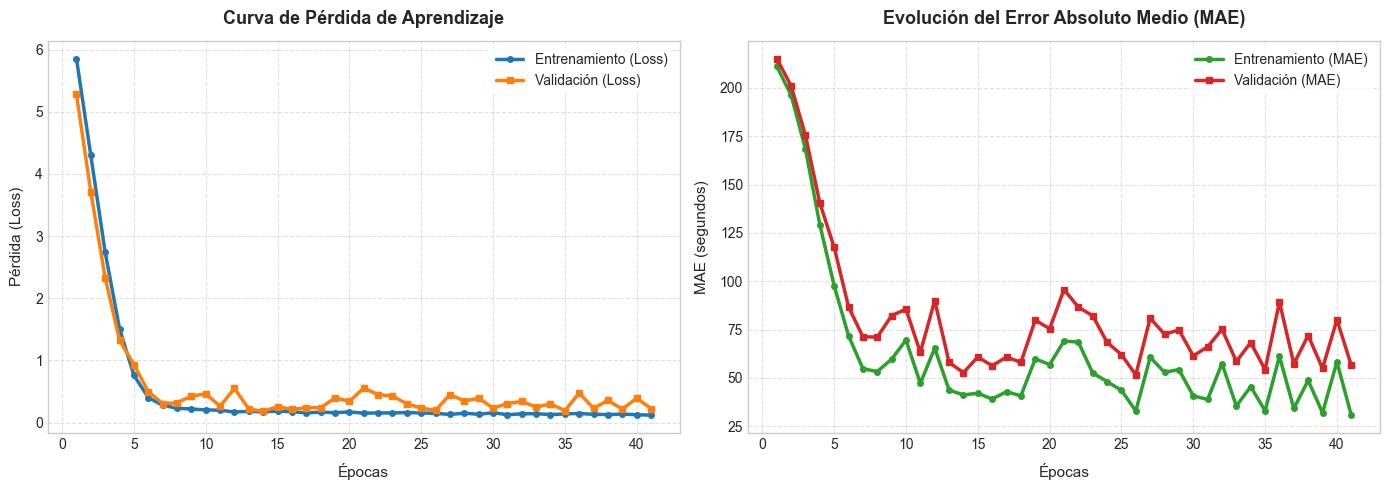

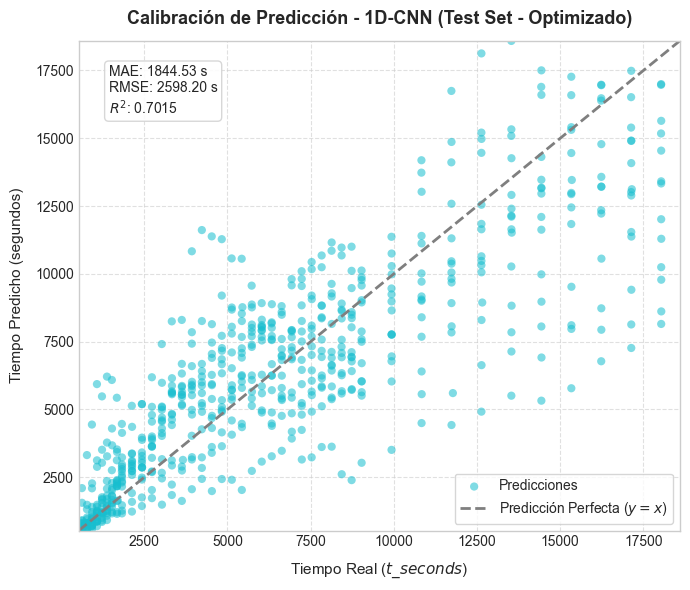

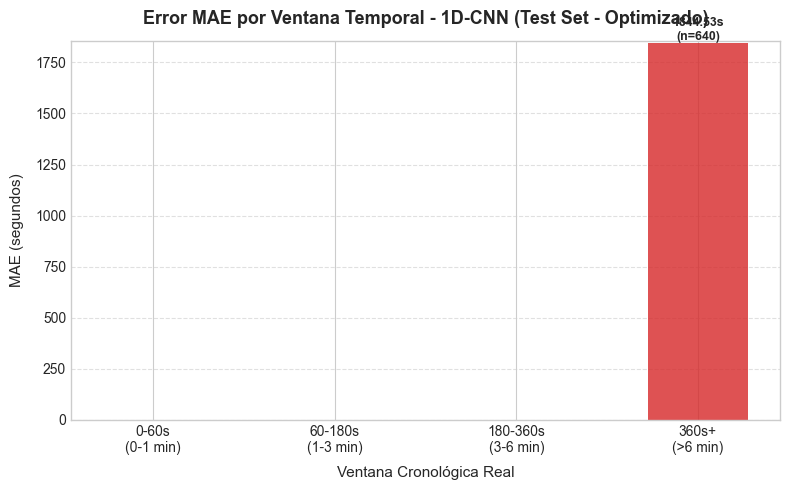

In [10]:
import numpy as np

# Cargar el modelo final entrenado para graficar y evaluar predicciones en Test
model_opt.load_state_dict(torch.load("../CNN1D_final.pt"))
model_opt.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x_seq, y in test_loader:
        x_seq, y = x_seq.to(dev), y.to(dev)
        pred = model_opt(x_seq)
        # Desescalar predicciones y reales
        y_true.extend((y.cpu().numpy() * CONFIG["time_scale"]).tolist())
        y_pred.extend((pred.cpu().numpy() * CONFIG["time_scale"]).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Curvas de aprendizaje del último fold de validación cruzada (Optimizado)
plot_learning_curves(histories_opt[-1])

# 2. Gráfico de Calibración de Predicciones en el Test Set
plot_prediction_calibration(y_true, y_pred, model_name="1D-CNN (Test Set - Optimizado)")

# 3. Distribución del error por ventana temporal en el Test Set
plot_error_by_time_window(y_true, y_pred, model_name="1D-CNN (Test Set - Optimizado)")